In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [4]:
# Plot style
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

In [5]:
# import data
df = pd.read_csv('data_ANN.csv')

In [6]:
# df = pd.DataFrame(data)

print("=== Dataset Overview ===")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nStatistics:")
print(df.describe())

=== Dataset Overview ===
   No.  phi  Ha       Ra       Nu
0    1  0.0   0     1000   7.7476
1    2  0.0   0    10000   7.7555
2    3  0.0   0   100000   8.8559
3    4  0.0   0  1000000  13.4330
4    5  0.0  20     1000   7.7475

Shape: (144, 5)

Statistics:
              No.         phi          Ha              Ra          Nu
count  144.000000  144.000000  144.000000      144.000000  144.000000
mean    72.500000    0.025000   50.000000   277750.000000    9.288892
std     41.713307    0.017138   34.275723   420245.907033    1.736707
min      1.000000    0.000000    0.000000     1000.000000    7.747500
25%     36.750000    0.010000   20.000000     7750.000000    8.200300
50%     72.500000    0.025000   50.000000    55000.000000    8.671090
75%    108.250000    0.040000   80.000000   325000.000000    9.518155
max    144.000000    0.050000  100.000000  1000000.000000   14.408424


In [7]:
X = df[['phi', 'Ha', 'Ra']]
y = df['Nu']

In [8]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Training samples : 115
Testing samples  : 29


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [11]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

In [13]:
def evaluate(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n--- {label} ---")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return r2, rmse, mae, mape

print("\n=== Evaluation Metrics ===")
r2_tr, rmse_tr, mae_tr, mape_tr = evaluate(y_train, y_pred_train, "Training Set")
r2_te, rmse_te, mae_te, mape_te = evaluate(y_test,  y_pred_test,  "Test Set")


=== Evaluation Metrics ===

--- Training Set ---
  R²   : 0.9991
  RMSE : 0.0516
  MAE  : 0.0297
  MAPE : 0.30%

--- Test Set ---
  R²   : 0.9962
  RMSE : 0.1058
  MAE  : 0.0626
  MAPE : 0.62%


In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2   = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_squared_error'))

print("\n=== 5-Fold Cross Validation ===")
print(f"  CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  CV RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")


=== 5-Fold Cross Validation ===
  CV R²   : 0.9906 ± 0.0104
  CV RMSE : 0.1402 ± 0.0492


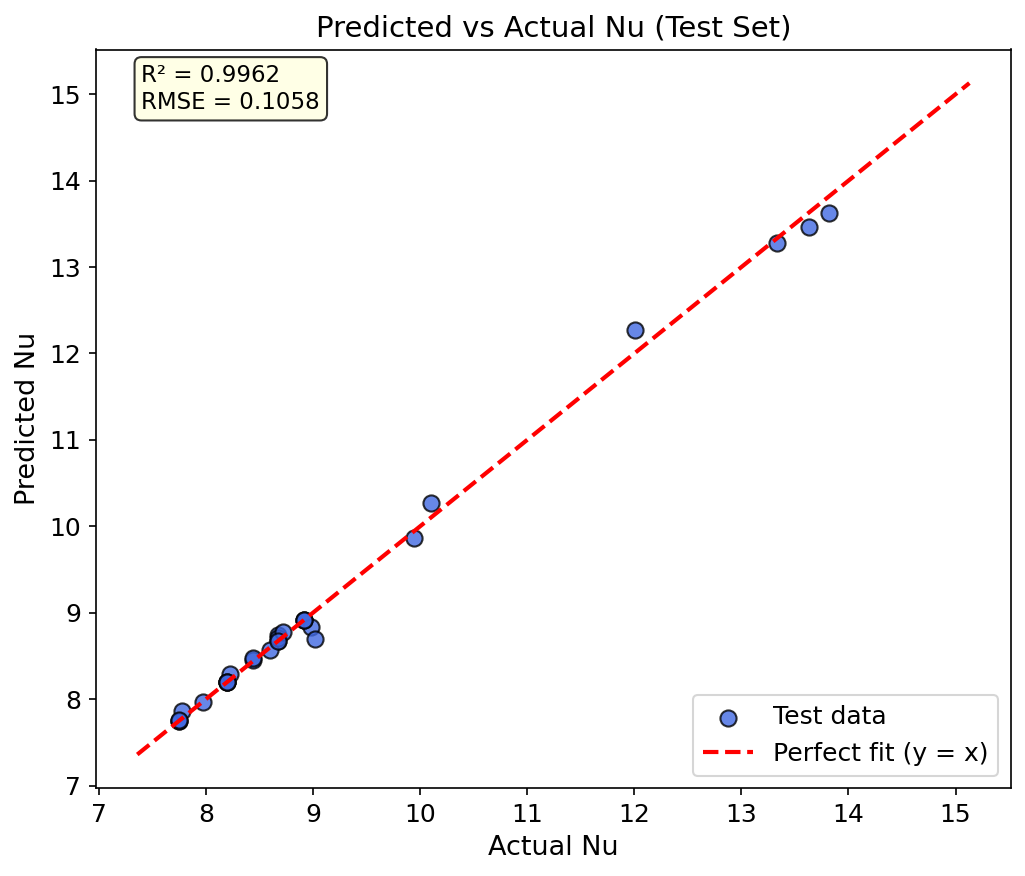

Saved: graph1_predicted_vs_actual.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_test, color='royalblue', edgecolors='k', alpha=0.8, s=60, label='Test data')
lims = [min(y.min(), y_pred_test.min()) * 0.95,
        max(y.max(), y_pred_test.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit (y = x)')
ax.set_xlabel('Actual Nu', fontsize=13)
ax.set_ylabel('Predicted Nu', fontsize=13)
ax.set_title('Predicted vs Actual Nu (Test Set)', fontsize=14)
ax.legend()
ax.text(0.05, 0.92, f'R² = {r2_te:.4f}\nRMSE = {rmse_te:.4f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
# plt.savefig('graph1_predicted_vs_actual.png', dpi=200)
plt.show()
print("Saved: graph1_predicted_vs_actual.png")

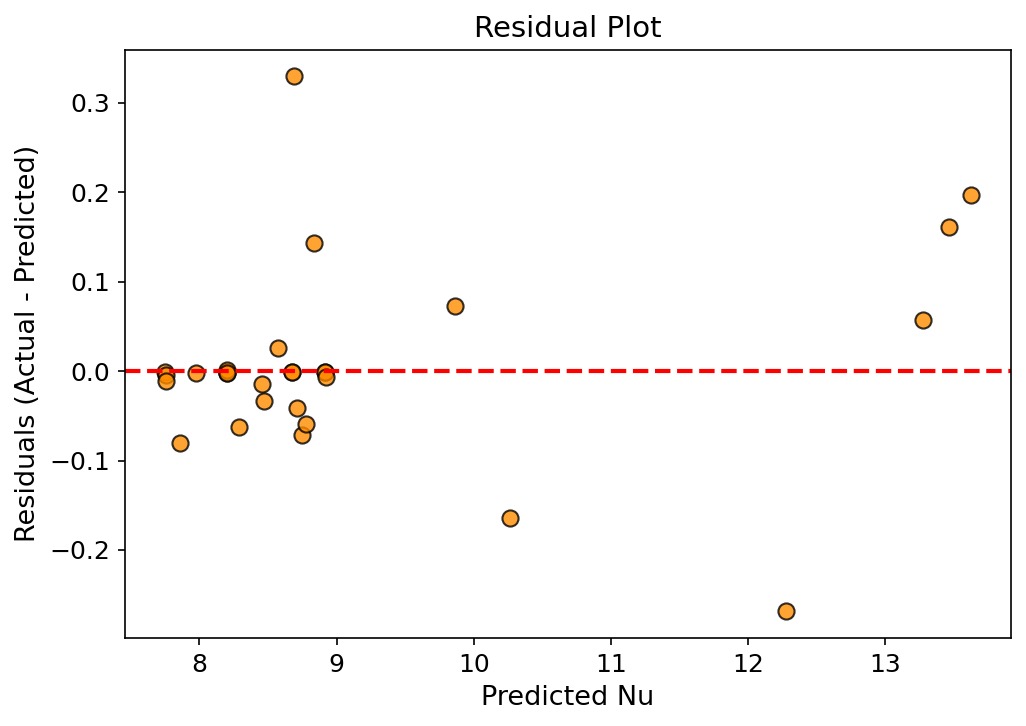

In [16]:
# --- Graph 2: Residual Plot ---
residuals = y_test - y_pred_test
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred_test, residuals, color='darkorange', edgecolors='k', alpha=0.8, s=60)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Predicted Nu', fontsize=13)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=13)
ax.set_title('Residual Plot', fontsize=14)
plt.tight_layout()
# plt.savefig('graph2_residuals.png', dpi=200)
plt.show()
# print("Saved: graph2_residuals.png")


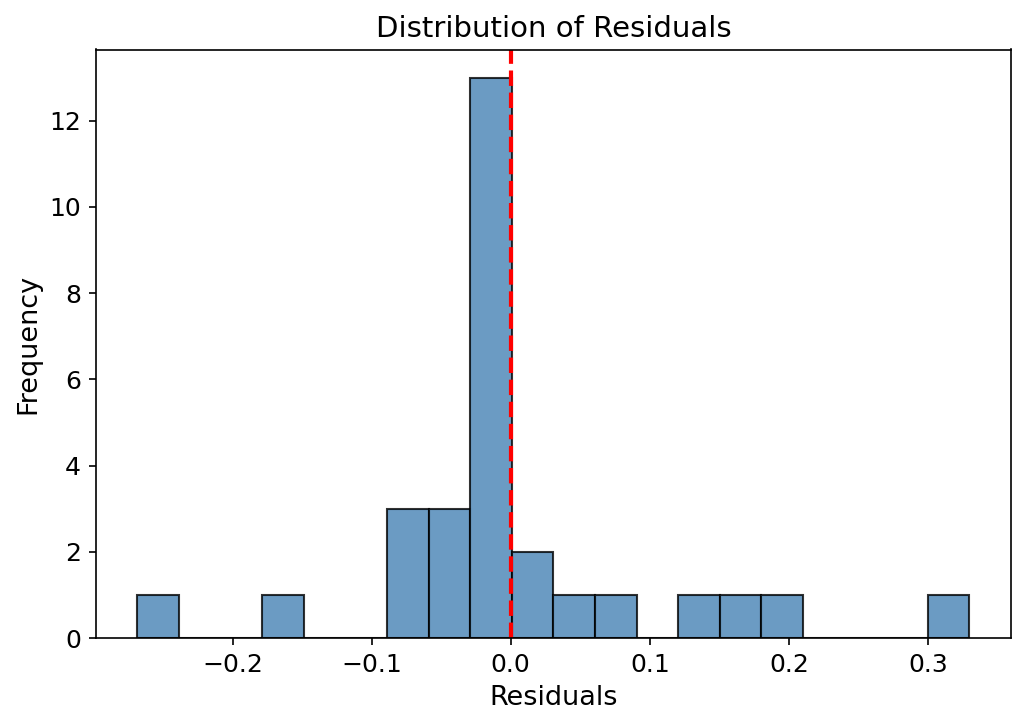

In [17]:
# --- Graph 3: Residual Distribution Histogram ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residuals', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Distribution of Residuals', fontsize=14)
plt.tight_layout()
# plt.savefig('graph3_residual_histogram.png', dpi=200)
plt.show()
# print("Saved: graph3_residual_histogram.png")

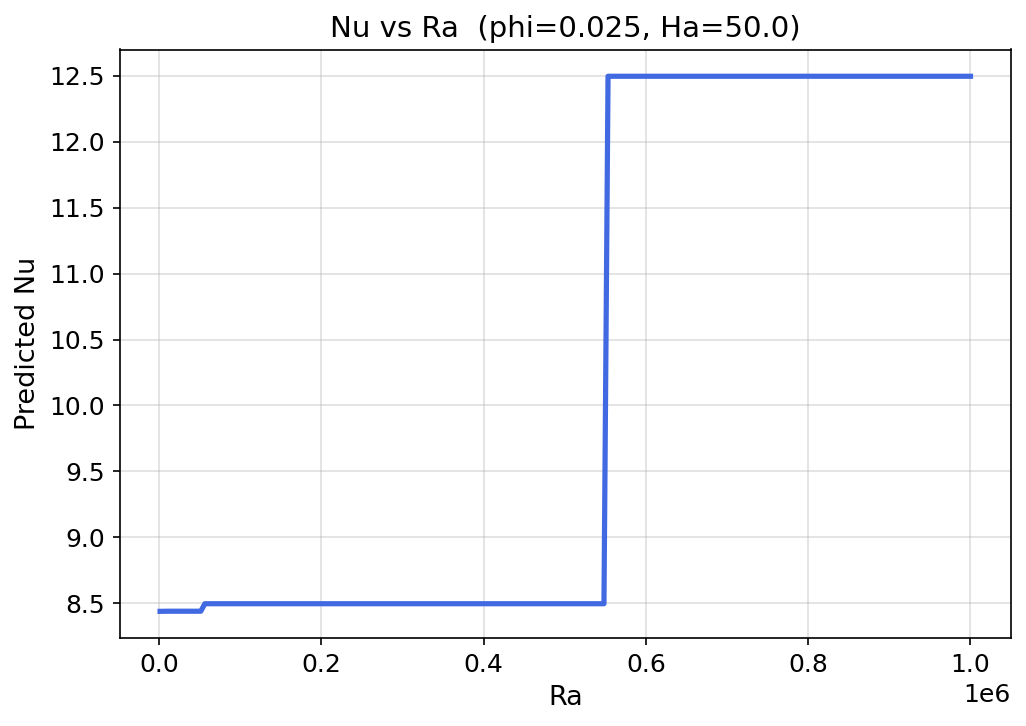

In [19]:
# --- Graph 5: Nu vs Ra (Physical Trend Check) ---
# Fix phi and Ha at their median, vary Ra
phi_fixed = df['phi'].median()
Ha_fixed  = df['Ha'].median()
Ra_range  = np.linspace(df['Ra'].min(), df['Ra'].max(), 200)
X_trend   = pd.DataFrame({'phi': phi_fixed, 'Ha': Ha_fixed, 'Ra': Ra_range})
Nu_trend  = rf_model.predict(X_trend)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Ra_range, Nu_trend, color='royalblue', lw=2.5)
ax.set_xlabel('Ra', fontsize=13)
ax.set_ylabel('Predicted Nu', fontsize=13)
ax.set_title(f'Nu vs Ra  (phi={phi_fixed}, Ha={Ha_fixed})', fontsize=14)
ax.grid(True, alpha=0.4)
plt.tight_layout()
# plt.savefig('graph5_Nu_vs_Ra.png', dpi=200)
plt.show()
# print("Saved: graph5_Nu_vs_Ra.png")

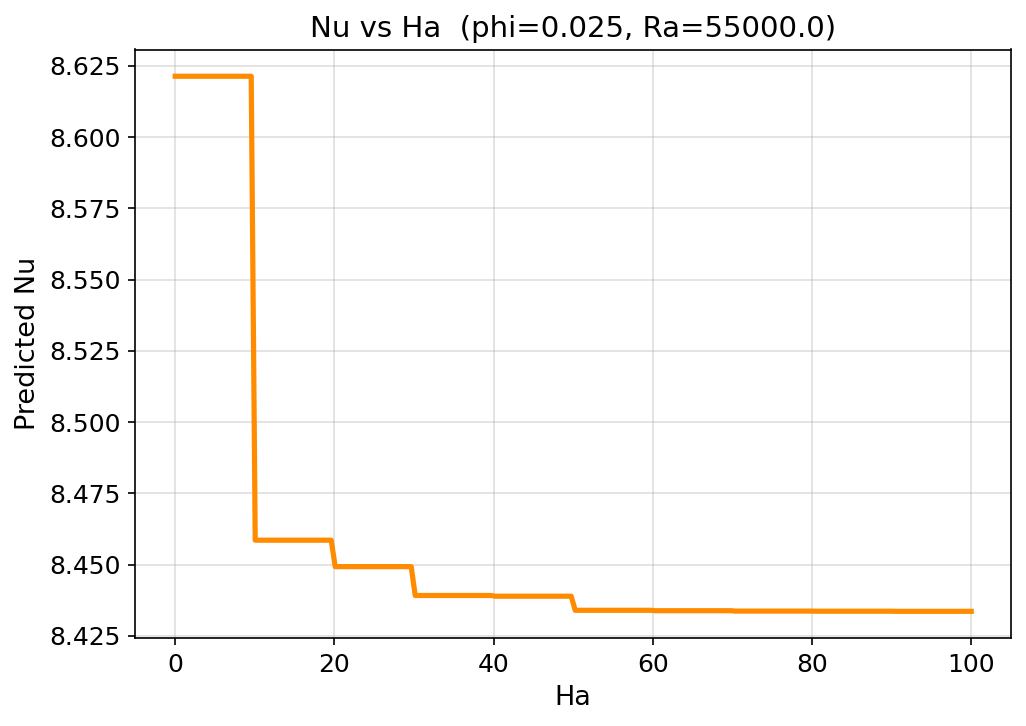

In [20]:
# --- Graph 6: Nu vs Ha (Physical Trend Check) ---
Ha_range  = np.linspace(df['Ha'].min(), df['Ha'].max(), 200)
Ra_fixed  = df['Ra'].median()
X_trend2  = pd.DataFrame({'phi': phi_fixed, 'Ha': Ha_range, 'Ra': Ra_fixed})
Nu_trend2 = rf_model.predict(X_trend2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Ha_range, Nu_trend2, color='darkorange', lw=2.5)
ax.set_xlabel('Ha', fontsize=13)
ax.set_ylabel('Predicted Nu', fontsize=13)
ax.set_title(f'Nu vs Ha  (phi={phi_fixed}, Ra={Ra_fixed})', fontsize=14)
ax.grid(True, alpha=0.4)
plt.tight_layout()
# plt.savefig('graph6_Nu_vs_Ha.png', dpi=200)
plt.show()
# print("Saved: graph6_Nu_vs_Ha.png")


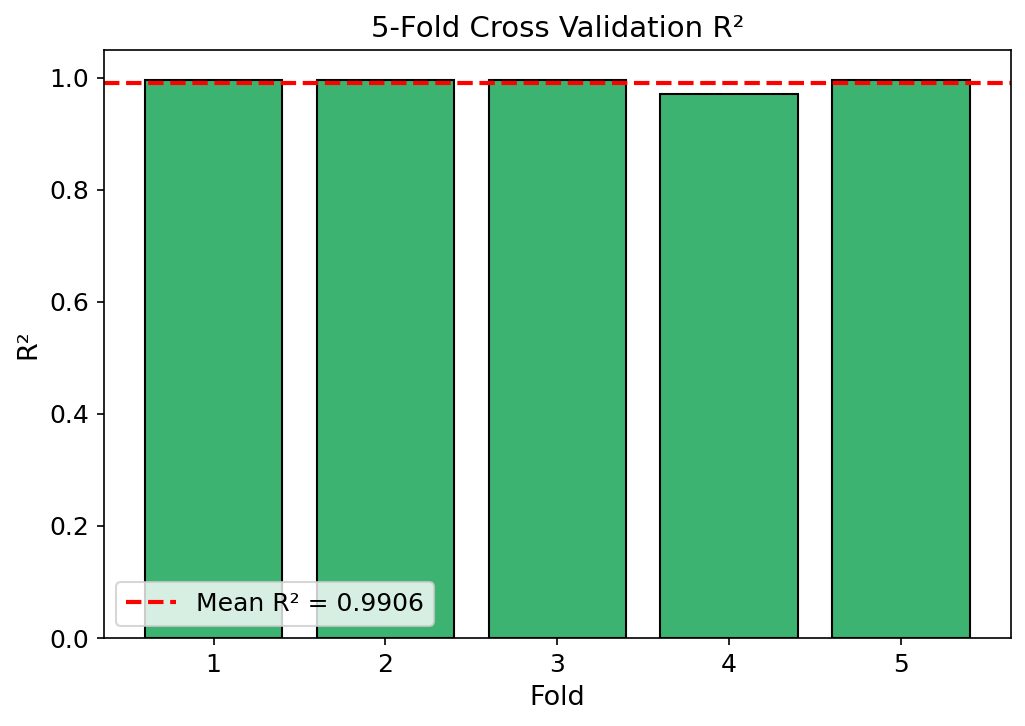

In [21]:
# --- Graph 7: Cross Validation R² per Fold ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(1, 6), cv_r2, color='mediumseagreen', edgecolor='black')
ax.axhline(cv_r2.mean(), color='red', linestyle='--', lw=2, label=f'Mean R² = {cv_r2.mean():.4f}')
ax.set_xlabel('Fold', fontsize=13)
ax.set_ylabel('R²', fontsize=13)
ax.set_title('5-Fold Cross Validation R²', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
# plt.savefig('graph7_cross_validation.png', dpi=200)
plt.show()
# print("Saved: graph7_cross_validation.png")

In [23]:
# STEP 9: METRICS SUMMARY TABLE
print("\n" + "="*45)
print("        FINAL METRICS SUMMARY")
print("="*45)
metrics_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE (%)'],
    'Train':  [f'{r2_tr:.4f}', f'{rmse_tr:.4f}', f'{mae_tr:.4f}', f'{mape_tr:.2f}'],
    'Test':   [f'{r2_te:.4f}', f'{rmse_te:.4f}', f'{mae_te:.4f}', f'{mape_te:.2f}'],
    'CV Mean':[f'{cv_r2.mean():.4f}', f'{cv_rmse.mean():.4f}', '-', '-']
})
print(metrics_df.to_string(index=False))


        FINAL METRICS SUMMARY
  Metric  Train   Test CV Mean
      R² 0.9991 0.9962  0.9906
    RMSE 0.0516 0.1058  0.1402
     MAE 0.0297 0.0626       -
MAPE (%)   0.30   0.62       -
